# 13. Event flag EDA — top cloud-pass 감지 신호 진단

**목적**: planner conditional 룰을 추가하기 전, 어떤 candidate signal이 실제 cloud-pass / ramp event를 잘 잡고 false positive는 얼마나 발생시키는지 정량화.

**다음 단계 (별도 작업)**: 본 EDA 결과를 바탕으로 `event_flag=1`일 때 planner의 ALPHA, GAP_THRESHOLD, hold 길이를 conditional하게 강화.

**범위 — 이번 노트북에서 보는 것**:
1. "true event hour" 정의 (portfolio shortfall 기준)
2. candidate signals — forward_gap, realized_gap, σ_p1, dc10Tca_target, drop_now_3h, 결합
3. 각 signal의 ROC / Precision-Recall
4. Top events 3개 day의 정오~15시 hour를 기준으로 TP/FP 매트릭스
5. 추천 threshold

**범위 — 이번 노트북에서 안 하는 것**:
- 새 forecast model 학습
- planner 룰 변경
- conditional branch 구현


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
import matplotlib as mpl, matplotlib.font_manager as fm
for f in ['Malgun Gothic','NanumGothic','AppleGothic']:
    if any(f.lower() in n.name.lower() for n in fm.fontManager.ttflist):
        mpl.rcParams['font.family'] = f; break
mpl.rcParams['axes.unicode_minus'] = False

ROOT = Path('../..').resolve()
print('ROOT:', ROOT)

# Phase 2 ensemble (test 2025) — 이미 (date, site, issue_hour, lead, target_dt) 구조
p2 = pd.read_parquet(ROOT / 'pv/experiments/phase2_intraday_tcn/ensemble_test.parquet')
p2['target_dt'] = pd.to_datetime(p2['target_dt'])
p2['date'] = pd.to_datetime(p2['date'])
print('Phase 2 ensemble rows:', len(p2))

# Planner v2 predictive log — realized_gap, forward_gap이 hour 단위로 이미 산출됨
log_p2 = pd.read_parquet(ROOT / 'pv/experiments/thermal_planner_v2/log_phase1plus2.parquet')
log_p2['datetime_kst'] = pd.to_datetime(log_p2['datetime_kst'])
log_p2['date'] = log_p2['datetime_kst'].dt.normalize()
print('planner log rows:', len(log_p2))

# Phase 1 ensemble (test) — actual + sigma 추가 정보
p1 = pd.read_parquet(ROOT / 'pv/experiments/resmlp_adaln_v2_ensemble/ensemble_test.parquet')
p1['datetime_kst'] = pd.to_datetime(p1['datetime_kst'])
print('Phase 1 ensemble rows:', len(p1))


ROOT: D:\pv_backup
Phase 2 ensemble rows: 66278
planner log rows: 3280
Phase 1 ensemble rows: 32443


## 1. True event hour 정의

운영 관점에서 event = "예측이 실제와 크게 어긋나서 thermal balancing 실패 위험이 큰 hour".

**정의 후보**:
- A. portfolio level shortfall_mw > X MW (planner residual 기반)
- B. portfolio |residual_mw| > X (over/under 모두 포함)
- C. realized hourly portfolio MAE > X% of capacity

여기서는 **A** 사용: `shortfall_mw > 5 MW` (= 약 portfolio cap 80MW의 6% 이상 부족).

이는 actual cf가 forecast 대비 크게 떨어져서 thermal이 못 따라간 시간을 의미.


In [2]:
# planner v2 log에서 hour 단위 portfolio shortfall 가져옴
log_p2['hour'] = log_p2.datetime_kst.dt.hour
df = log_p2[log_p2.hour.between(9, 17)].copy()
df['true_event'] = (df['shortfall_mw'] > 5.0).astype(int)
df['true_severe'] = (df['shortfall_mw'] > 10.0).astype(int)
print(f'전체 daytime hours: {len(df):,}')
print(f"true_event   (shortfall > 5 MW):  {df.true_event.sum():,} ({df.true_event.mean()*100:.2f}%)")
print(f"true_severe  (shortfall > 10 MW): {df.true_severe.sum():,} ({df.true_severe.mean()*100:.2f}%)")
print()

# Top event days의 정오~15시 hours
events = pd.to_datetime(['2025-03-23','2025-04-26','2025-05-04'])
ev_mask = df.date.isin(events) & df.hour.between(12, 15)
print('Top event days (12~15h):')
print(df[ev_mask][['date','hour','shortfall_mw','true_event','true_severe']].to_string(index=False))


전체 daytime hours: 3,280
true_event   (shortfall > 5 MW):  203 (6.19%)
true_severe  (shortfall > 10 MW): 44 (1.34%)

Top event days (12~15h):
      date  hour  shortfall_mw  true_event  true_severe
2025-03-23    12     39.654535           1            1
2025-03-23    13     31.581703           1            1
2025-03-23    14     20.504295           1            1
2025-03-23    15      4.556075           0            0
2025-04-26    12      1.979477           0            0
2025-04-26    13     42.962828           1            1
2025-04-26    14     30.177368           1            1
2025-04-26    15      0.000000           0            0
2025-05-04    12     42.893341           1            1
2025-05-04    13     34.487315           1            1
2025-05-04    14     22.934773           1            1
2025-05-04    15      0.000000           0            0


→ true_event 정의가 합리적인지 확인 — top event 12~15h가 모두 잡혀야 함.


## 2. Candidate signals — planner log에서 직접 추출

planner v2 log는 이미 forward_gap, realized_gap, σ_p1을 hour 단위로 가지고 있음. weather signal은 source data에서 추가로 join.


In [3]:
# 추가 signal: dc10Tca_target, drop_now_3h
ws = pd.read_parquet(ROOT / 'data/processed/training_set.parquet')
ws['datetime_kst'] = pd.to_datetime(ws['datetime_kst'])
ws = ws.sort_values(['site','datetime_kst'])
# portfolio aggregate weather (cap-weighted dc10Tca)
ws['cap'] = ws['site_capacity_kw']
ws['dc_w'] = ws['dc10Tca'] * ws['cap']
ws_port = ws.groupby('datetime_kst', as_index=False).agg(dc_sum=('dc_w','sum'), cap=('cap','sum'))
ws_port['dc10Tca_port'] = ws_port['dc_sum'] / ws_port['cap']

# drop_now_3h: site 평균 → portfolio
ws['cf'] = ws['cf'].fillna(0)
ws['cap_kw'] = ws['site_capacity_kw']
ws['gen_kw'] = ws['cf'] * ws['cap_kw']
ws_g = ws.groupby('datetime_kst', as_index=False).agg(gen_kw=('gen_kw','sum'), cap=('cap_kw','sum'))
ws_g['port_cf'] = ws_g['gen_kw'] / ws_g['cap']
ws_g = ws_g.sort_values('datetime_kst').reset_index(drop=True)
ws_g['drop_now_3h'] = ws_g['port_cf'].diff().rolling(3, min_periods=1).apply(
    lambda x: -min(x.min(), 0) if len(x) > 0 else 0, raw=True).fillna(0)

# merge with planner log
df = df.merge(ws_port[['datetime_kst','dc10Tca_port']], on='datetime_kst', how='left')
df = df.merge(ws_g[['datetime_kst','drop_now_3h']], on='datetime_kst', how='left')

# 신호 후보들
df['abs_forward_gap'] = df['forward_gap'].abs()
df['abs_realized_gap'] = df['realized_gap'].abs()
df['gap_x_sigma'] = df['abs_forward_gap'] * df['sigma_mw']    # joint signal

print('candidate signals:')
print(df[['abs_forward_gap','abs_realized_gap','sigma_mw','dc10Tca_port','drop_now_3h','gap_x_sigma']].describe().round(2).T)


candidate signals:
                   count   mean    std   min   25%   50%    75%     max
abs_forward_gap   3280.0   2.13   3.51  0.00  0.70  1.47   2.60   54.86
abs_realized_gap  3280.0   2.69   4.38  0.00  0.54  1.61   3.15   56.08
sigma_mw          3280.0   5.88   3.28  0.94  3.06  5.25   8.26   16.26
dc10Tca_port      3280.0   4.70   3.63  0.00  0.77  4.75   8.22   10.00
drop_now_3h       3280.0   0.06   0.09  0.00  0.00  0.01   0.11    0.65
gap_x_sigma       3280.0  14.87  32.63  0.00  2.65  7.07  16.36  627.00


## 3. 각 signal의 ROC / Precision-Recall

threshold를 sweep하면서 TP rate / FP rate / precision / recall 계산.


In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

SIGNALS = ['abs_forward_gap','abs_realized_gap','sigma_mw','dc10Tca_port','drop_now_3h','gap_x_sigma']

print('=== ROC AUC and PR Average Precision (target = true_event, shortfall > 5 MW) ===')
print(f"  {'signal':<22} {'ROC AUC':>10} {'PR AP':>10} {'n_pos':>7}")
for sig in SIGNALS:
    s = df[[sig, 'true_event']].dropna()
    if len(s) < 100 or s.true_event.sum() == 0: continue
    auc = roc_auc_score(s.true_event, s[sig])
    ap = average_precision_score(s.true_event, s[sig])
    print(f'  {sig:<22} {auc:>10.3f} {ap:>10.3f} {int(s.true_event.sum()):>7}')

print('\n=== Severe events (shortfall > 10 MW) ===')
print(f"  {'signal':<22} {'ROC AUC':>10} {'PR AP':>10} {'n_pos':>7}")
for sig in SIGNALS:
    s = df[[sig, 'true_severe']].dropna()
    if len(s) < 100 or s.true_severe.sum() == 0: continue
    auc = roc_auc_score(s.true_severe, s[sig])
    ap = average_precision_score(s.true_severe, s[sig])
    print(f'  {sig:<22} {auc:>10.3f} {ap:>10.3f} {int(s.true_severe.sum()):>7}')


=== ROC AUC and PR Average Precision (target = true_event, shortfall > 5 MW) ===
  signal                    ROC AUC      PR AP   n_pos
  abs_forward_gap             0.666      0.302     203
  abs_realized_gap            0.714      0.160     203
  sigma_mw                    0.678      0.127     203
  dc10Tca_port                0.599      0.072     203
  drop_now_3h                 0.766      0.263     203
  gap_x_sigma                 0.700      0.298     203

=== Severe events (shortfall > 10 MW) ===
  signal                    ROC AUC      PR AP   n_pos
  abs_forward_gap             0.867      0.608      44
  abs_realized_gap            0.835      0.134      44
  sigma_mw                    0.730      0.042      44
  dc10Tca_port                0.432      0.012      44
  drop_now_3h                 0.942      0.456      44
  gap_x_sigma                 0.873      0.551      44


→ **판독**: ROC AUC > 0.75는 강한 분류기, > 0.85는 매우 강함. PR AP는 클래스 불균형이 클 때 더 정직한 metric.


## 4. ROC / PR 곡선 시각화


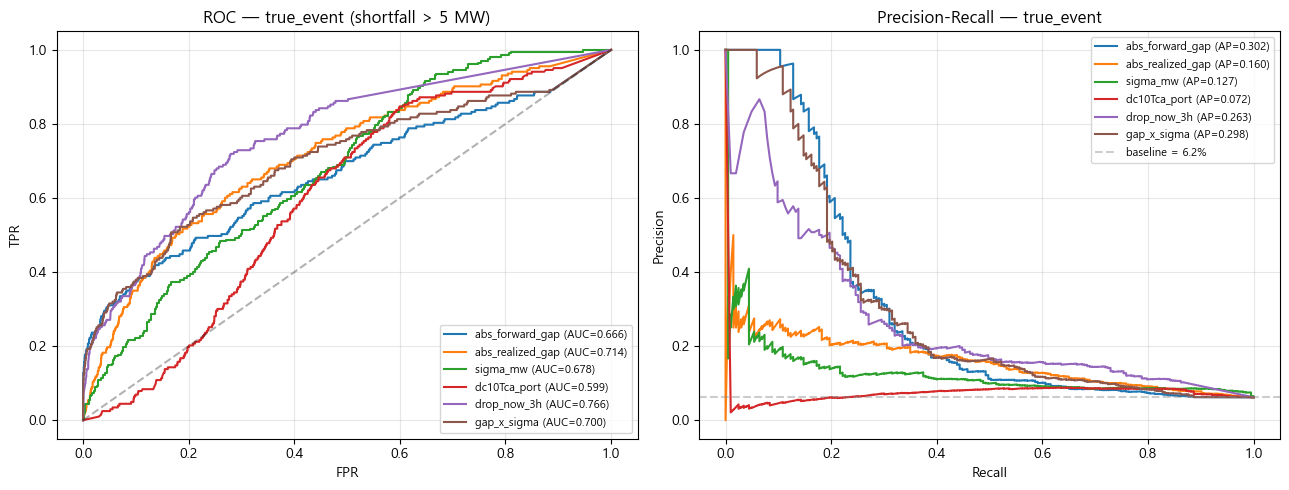

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for sig in SIGNALS:
    s = df[[sig,'true_event']].dropna()
    if s.true_event.sum() == 0: continue
    fpr, tpr, _ = roc_curve(s.true_event, s[sig])
    auc = roc_auc_score(s.true_event, s[sig])
    axes[0].plot(fpr, tpr, label=f'{sig} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — true_event (shortfall > 5 MW)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# PR
for sig in SIGNALS:
    s = df[[sig,'true_event']].dropna()
    if s.true_event.sum() == 0: continue
    pr, rc, _ = precision_recall_curve(s.true_event, s[sig])
    ap = average_precision_score(s.true_event, s[sig])
    axes[1].plot(rc, pr, label=f'{sig} (AP={ap:.3f})')
axes[1].axhline(df.true_event.mean(), color='gray', ls='--', alpha=0.4,
                label=f'baseline = {df.true_event.mean()*100:.1f}%')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — true_event')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 5. 운영 의미 있는 threshold — Confusion matrix at fixed cut

각 signal에서 *recall = 0.7 / 0.5* 점에서의 precision 및 false positive 수.


In [6]:
def at_recall(y, score, target_recall=0.7):
    pr, rc, th = precision_recall_curve(y, score)
    # rc/pr/th align: th has len-1, last point is rc=0/pr=1
    idx = np.searchsorted(-rc, -target_recall)  # find smallest threshold with rc >= target
    if idx >= len(th): return None
    return {'threshold': th[idx], 'precision': pr[idx], 'recall': rc[idx],
            'tp': int(((score >= th[idx]) & (y == 1)).sum()),
            'fp': int(((score >= th[idx]) & (y == 0)).sum()),
            'fn': int(((score < th[idx]) & (y == 1)).sum()),
            'flag_rate': float((score >= th[idx]).mean())}

print('=== signal별 — recall 0.7 점에서 ===')
for sig in SIGNALS:
    s = df[[sig,'true_event']].dropna()
    if s.true_event.sum() < 5: continue
    r = at_recall(s.true_event.values, s[sig].values, 0.7)
    if r:
        print(f"  {sig:<22} thr={r['threshold']:>7.3f}  "
              f"P={r['precision']:.3f}  R={r['recall']:.3f}  "
              f"TP={r['tp']} FP={r['fp']} FN={r['fn']}  flag_rate={r['flag_rate']*100:.1f}%")

print('\n=== signal별 — recall 0.5 점에서 ===')
for sig in SIGNALS:
    s = df[[sig,'true_event']].dropna()
    if s.true_event.sum() < 5: continue
    r = at_recall(s.true_event.values, s[sig].values, 0.5)
    if r:
        print(f"  {sig:<22} thr={r['threshold']:>7.3f}  "
              f"P={r['precision']:.3f}  R={r['recall']:.3f}  "
              f"TP={r['tp']} FP={r['fp']} FN={r['fn']}  flag_rate={r['flag_rate']*100:.1f}%")


=== signal별 — recall 0.7 점에서 ===
  abs_forward_gap        thr=  1.402  P=0.083  R=0.700  TP=142 FP=1576 FN=61  flag_rate=52.4%
  abs_realized_gap       thr=  2.024  P=0.104  R=0.700  TP=142 FP=1222 FN=61  flag_rate=41.6%
  sigma_mw               thr=  5.186  P=0.085  R=0.700  TP=142 FP=1529 FN=61  flag_rate=50.9%
  dc10Tca_port           thr=  4.678  P=0.086  R=0.700  TP=142 FP=1515 FN=61  flag_rate=50.5%
  drop_now_3h            thr=  0.087  P=0.144  R=0.700  TP=142 FP=846 FN=61  flag_rate=30.1%
  gap_x_sigma            thr=  9.447  P=0.105  R=0.700  TP=142 FP=1213 FN=61  flag_rate=41.3%

=== signal별 — recall 0.5 점에서 ===
  abs_forward_gap        thr=  2.413  P=0.111  R=0.498  TP=101 FP=806 FN=102  flag_rate=27.7%
  abs_realized_gap       thr=  3.903  P=0.157  R=0.498  TP=101 FP=542 FN=102  flag_rate=19.6%
  sigma_mw               thr=  7.393  P=0.099  R=0.498  TP=101 FP=923 FN=102  flag_rate=31.2%
  dc10Tca_port           thr=  6.830  P=0.083  R=0.498  TP=101 FP=1113 FN=102  flag_rate

→ **판독 기준**:
- recall 0.7에서 precision > 0.5면 좋은 신호 — 운영 conditional 룰 후보.
- flag_rate가 너무 높으면 (예: 30%+) "거의 항상 강하게 대응" → false alarm fatigue.
- flag_rate 5~15% 정도가 "선택적 강 대응" 운영 수준.


## 6. Joint signal — combined rule 평가

단일 signal보다 결합이 더 강한지: `forward_gap > X AND dc10Tca > Y` 같은 AND 룰.


In [7]:
# 매뉴얼 grid search: forward_gap × dc10Tca threshold 조합
print('=== Combined: |forward_gap| > Tg AND dc10Tca > Tc ===')
print(f"  {'Tg(MW)':>7} {'Tc':>5}   {'flag_rate':>10}  {'precision':>10}  {'recall':>8}  {'TP':>4} {'FP':>5}")
for Tg in [3, 5, 8, 10, 15]:
    for Tc in [0, 3, 5, 7]:
        flag = ((df.abs_forward_gap > Tg) & (df.dc10Tca_port > Tc)).astype(int)
        s = pd.DataFrame({'flag': flag, 'y': df.true_event}).dropna()
        if s.flag.sum() == 0: continue
        tp = ((s.flag == 1) & (s.y == 1)).sum()
        fp = ((s.flag == 1) & (s.y == 0)).sum()
        fn = ((s.flag == 0) & (s.y == 1)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        print(f'  {Tg:>7} {Tc:>5}   {s.flag.mean()*100:>9.1f}%  {precision:>10.3f}  {recall:>8.3f}  {tp:>4} {fp:>5}')

print('\n=== Top event hours coverage at each rule ===')
for Tg, Tc in [(5, 5), (8, 3), (10, 3), (8, 5)]:
    flag = (df.abs_forward_gap > Tg) & (df.dc10Tca_port > Tc)
    ev_sub = df[df.date.isin(events) & df.hour.between(12, 15)]
    ev_flag_rate = ((ev_sub.abs_forward_gap > Tg) & (ev_sub.dc10Tca_port > Tc)).mean() * 100
    overall_flag_rate = flag.mean() * 100
    print(f'  rule (|fg|>{Tg} AND dc>{Tc}): top events 12~15h flag_rate={ev_flag_rate:.0f}%   overall flag_rate={overall_flag_rate:.1f}%')


=== Combined: |forward_gap| > Tg AND dc10Tca > Tc ===
   Tg(MW)    Tc    flag_rate   precision    recall    TP    FP
        3     0        18.6%       0.131     0.394    80   530
        3     3        14.6%       0.132     0.310    63   416
        3     5        11.9%       0.115     0.222    45   345
        3     7         8.0%       0.091     0.118    24   240
        5     0         5.8%       0.272     0.256    52   139
        5     3         4.6%       0.245     0.182    37   114
        5     5         3.6%       0.179     0.103    21    96
        5     7         2.4%       0.128     0.049    10    68
        8     0         1.6%       0.569     0.143    29    22
        8     3         1.2%       0.513     0.099    20    19
        8     5         0.8%       0.480     0.059    12    13
        8     7         0.4%       0.462     0.030     6     7
       10     0         1.0%       0.706     0.118    24    10
       10     3         0.8%       0.630     0.084    17    10
 

## 7. 결론 분기 (운영 conditional 룰 후보)

| 결과 | 다음 단계 |
|---|---|
| 단일 signal AUC > 0.85 + recall 0.7에서 precision > 0.5 | 그 signal threshold만으로 conditional 룰 충분 |
| 단일 signal 약함 + 결합 룰 (AND) recall > 0.7 + precision > 0.5 | 결합 룰 채택 |
| 결합도 precision < 0.4 | event_flag 자체가 noisy → planner 강 대응 룰 보류 |

**다음 작업 (별도)**:
- 추천된 event_flag를 planner v2에 conditional rule로 추가
- `event_flag=1` → `ALPHA = 0.9` (기본 0.6), `THR_LOW = 1 MW` (기본 3 MW), `RELEASE_RATE = 2 MW/h` (기본 4)
- planner v3로 저장하고 v2와 KPI 비교 (shortfall, peaker_starts, oscillation)
